Biblioteki

In [ ]:
import json
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

Wczytanie pliku JSON z adnotacjami COCO

In [ ]:
def load_coco_annotations(json_path):
    """
    Wczytuje adnotacje COCO z pliku JSON.

    Parameters
    ----------
    json_path : str
        Ścieżka do pliku JSON.

    Returns
    -------
    dict
        Słownik zawierający dane COCO.
    """

    with open(json_path, "r") as f:
        coco = json.load(f)

    return coco

Wczytanie zdjęcia

In [ ]:
def load_image(image_path):
    """
    Wczytuje zdjęcie i konwertuje je z BGR do RGB.

    Parameters
    ----------
    image_path : str
        Ścieżka do zdjęcia.

    Returns
    -------
    np.ndarray
        Obraz w formacie RGB.
    """

    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(
            f"Nie udało się wczytać obrazu: {image_path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    return image

Wczytanie adnotacji danego zdjecia

In [ ]:
def load_annotations(coco,image_id):
  """
  Wczytuje adnotacje zdjęcia o podanym ID.

  Parameters
  ----------
  coco : dict
    Słownik zawierający dane COCO.

  image_id : int
    Identyfikator zdjecia.

  Returns
  -------
  list
    Lista adnotacji
  """

  annotations = []

  for annotation in coco["annotations"]:
    if annotation["image_id"] == image_id:
      annotations.append(annotation)

  return annotations

Tworzenie maski do zdjecia na podstawie adnotacji

In [ ]:
def create_mask(image_info, annotations):
  """
  Tworzy maskę dla zdjęcia na podstawie adnotacji.

  Parameters
  ----------


  Returns
  -------
  np.ndarray
    Maska zdjęcia.
  """

  # Tlo skladajace sie z zer
  height = image_info["height"]
  width = image_info["width"]

  mask = np.zeros((height, width), dtype=np.uint8) # uint8 - int o wielkosci 8 bitow - 256 wartosci

  # Uzupelnienie maski kategoriami
  for annotation in annotations:

    category_id = annotation["category_id"]

    polygon = np.array(
        annotation["segmentation"][0],
        dtype=np.int32
    )

    polygon = polygon.reshape(-1, 2)

    cv2.fillPoly(
        mask,
        [polygon],
        category_id
    )

  return mask

Wizualizacja maski

In [ ]:
def visualize_image_and_mask(image, mask):
    """
    Wyświetla zdjęcie oraz odpowiadającą mu maskę.
    """

    plt.figure(figsize=(12, 6))

    # Oryginalne zdjęcie
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Oryginalne zdjęcie")
    plt.axis("off")

    # Maska
    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.title("Maska")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

#MAIN

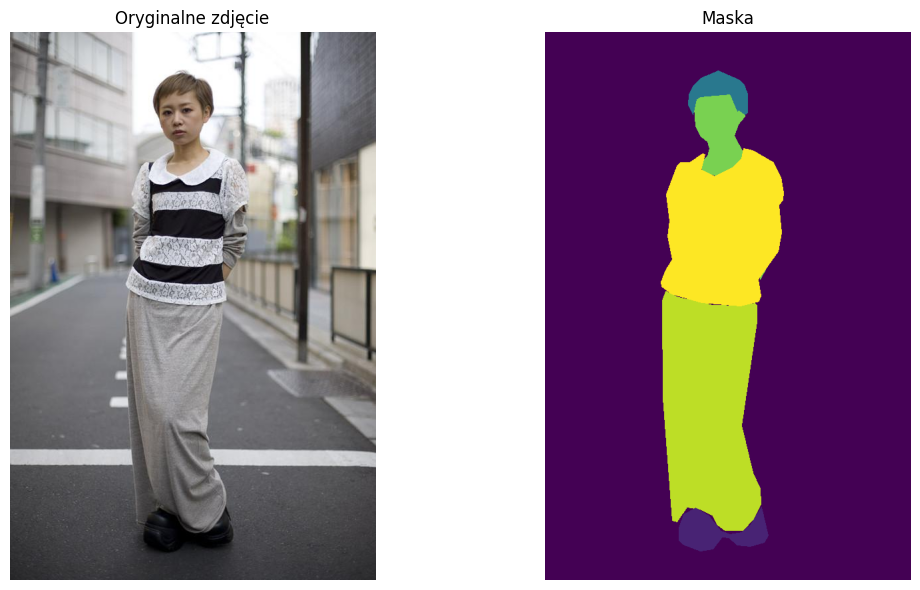

In [ ]:
# Static
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/INZ/dataset/train"
JSON_PATH = "/content/drive/MyDrive/Colab Notebooks/INZ/dataset/_annotations.coco.json"

# Wczytanie JSON
coco = load_coco_annotations(JSON_PATH)

# Wyswietlenie obrazu
image_info = coco["images"][0]

image_path = os.path.join(DATASET_PATH, image_info["file_name"])

image = load_image(image_path)

# Wyswietlenie obrazu
# plt.imshow(image)
# plt.axis("off")
# plt.title("Oryginalne zdjęcie")

# plt.show()

# Adnotacje do obrazu
annotations = load_annotations(coco,image_info["id"])

# Tworzenie maski dla obrazu
mask = create_mask(image_info,annotations)

# Wyswietlenie maski
visualize_image_and_mask(image,mask)
